# Exploration Numérique du Paradoxe de Condorcet

Ce notebook permet d'explorer expérimentalement le **paradoxe de Condorcet** à travers :
1. La simulation de cas réels (politique, choix d'entreprise, délibération de groupe).
2. L'analyse de Monte-Carlo sous l'hypothèse de l'*Impartial Culture*.
3. La visualisation graphique des probabilités de survenue des cycles de vote.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ajout du dossier source au PATH pour importer notre module condorcet
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

from condorcet import Candidate, Voter, Tournament, CondorcetSimulation

# Configuration esthétique des graphiques
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 14
})

# Création du dossier d'exportation pour les images
os.makedirs('../assets', exist_ok=True)
print("Environnement configuré avec succès.")

Environnement configuré avec succès.


## 1. Cas d'école classique : Le Paradoxe à 3 Votants et 3 Candidats

Considérons trois électeurs aux préférences cycliques :
* Votant 1 : $A \succ B \succ C$
* Votant 2 : $B \succ C \succ A$
* Votant 3 : $C \succ A \succ B$

In [2]:
cand_A = Candidate("A")
cand_B = Candidate("B")
cand_C = Candidate("C")
candidats_base = [cand_A, cand_B, cand_C]

v1 = Voter("V1", [cand_A, cand_B, cand_C])
v2 = Voter("V2", [cand_B, cand_C, cand_A])
v3 = Voter("V3", [cand_C, cand_A, cand_B])

tournoi_classique = Tournament(candidats_base, [v1, v2, v3])

print("Matrice des duels :")
for duel in tournoi_classique.duels:
    vainqueur = duel.get_winner()
    if vainqueur:
        perdant = duel.candidate_b if vainqueur == duel.candidate_a else duel.candidate_a
        voix_g = max(duel.votes_a, duel.votes_b)
        voix_p = min(duel.votes_a, duel.votes_b)
        print(f"  - {duel.candidate_a} vs {duel.candidate_b} : {vainqueur} bat {perdant} ({voix_g} contre {voix_p})")
    else:
        print(f"  - {duel.candidate_a} vs {duel.candidate_b} : Égalité ({duel.votes_a} - {duel.votes_b})")

print(f"\nVainqueur de Condorcet : {tournoi_classique.get_condorcet_winner()}")
print(f"Présence d'un cycle de Condorcet : {tournoi_classique.has_cycle()}")

Matrice des duels :
  - A vs B : A bat B (2 contre 1)
  - A vs C : C bat A (2 contre 1)
  - B vs C : B bat C (2 contre 1)

Vainqueur de Condorcet : None
Présence d'un cycle de Condorcet : True


## 2. Cas Concret : Choix d'un Siège Social en Entreprise

Trois options de localisation sont soumises à 100 salariés :
* **P** : Paris (Centre)
* **L** : Lyon (Périphérie)
* **B** : Bordeaux (Gare TGV)

Répartition des effectifs :
* 40 salariés : $P \succ L \succ B$
* 35 salariés : $L \succ B \succ P$
* 25 salariés : $B \succ P \succ L$

In [3]:
P, L, B = Candidate("Paris"), Candidate("Lyon"), Candidate("Bordeaux")
candidats_entreprise = [P, L, B]

votants_entreprise = []
for i in range(40):
    votants_entreprise.append(Voter(f"Salarié_P_{i}", [P, L, B]))
for i in range(35):
    votants_entreprise.append(Voter(f"Salarié_L_{i}", [L, B, P]))
for i in range(25):
    votants_entreprise.append(Voter(f"Salarié_B_{i}", [B, P, L]))

tournoi_entreprise = Tournament(candidats_entreprise, votants_entreprise)

print("Résultats des duels en entreprise :")
for duel in tournoi_entreprise.duels:
    vainqueur = duel.get_winner()
    if vainqueur:
        perdant = duel.candidate_b if vainqueur == duel.candidate_a else duel.candidate_a
        voix_g = max(duel.votes_a, duel.votes_b)
        voix_p = min(duel.votes_a, duel.votes_b)
        print(f"  - {duel.candidate_a} vs {duel.candidate_b} : {vainqueur} bat {perdant} ({voix_g} voix contre {voix_p})")
    else:
        print(f"  - {duel.candidate_a} vs {duel.candidate_b} : Égalité ({duel.votes_a} - {duel.votes_b})")

print(f"\nVainqueur de Condorcet : {tournoi_entreprise.get_condorcet_winner()}")
print(f"Présence d'un cycle : {tournoi_entreprise.has_cycle()}")
print(f"Scores de Borda : {tournoi_entreprise.get_borda_scores()}")
print(f"Vainqueur de Borda : {tournoi_entreprise.get_borda_winner()}")

Résultats des duels en entreprise :
  - Paris vs Lyon : Paris bat Lyon (65 voix contre 35)
  - Paris vs Bordeaux : Bordeaux bat Paris (60 voix contre 40)
  - Lyon vs Bordeaux : Lyon bat Bordeaux (75 voix contre 25)

Vainqueur de Condorcet : None
Présence d'un cycle : True
Scores de Borda : {Candidate('Paris'): 105, Candidate('Lyon'): 110, Candidate('Bordeaux'): 85}
Vainqueur de Borda : Lyon


## 3. Simulation Monte-Carlo (Modèle *Impartial Culture*)

Nous évaluons empiriquement la probabilité d'apparition d'un cycle majoritaire en faisant varier :
* Le nombre de candidats $M \in [3, 8]$
* Le nombre d'électeurs $N \in [3, 101]$ (nombres impairs)

In [4]:
nb_iterations = 2000
candidats_liste = [3, 4, 5, 6, 7]
votants_liste = [3, 11, 31, 51, 101]

resultats = np.zeros((len(candidats_liste), len(votants_liste)))

for i, m in enumerate(candidats_liste):
    for j, n in enumerate(votants_liste):
        sim = CondorcetSimulation(num_candidates=m, num_voters=n)
        p = sim.run_simulation(iterations=nb_iterations)
        resultats[i, j] = p['cycle_probability']
        print(f"M = {m:2d} candidats | N = {n:3d} votants -> P(Cycle) = {p['cycle_probability']:.4f}")

df_resultats = pd.DataFrame(
    resultats, 
    index=[f"{m} candidats" for m in candidats_liste],
    columns=[f"{n} votants" for n in votants_liste]
)

M =  3 candidats | N =   3 votants -> P(Cycle) = 5.6000
M =  3 candidats | N =  11 votants -> P(Cycle) = 7.9000
M =  3 candidats | N =  31 votants -> P(Cycle) = 7.7500
M =  3 candidats | N =  51 votants -> P(Cycle) = 9.1500
M =  3 candidats | N = 101 votants -> P(Cycle) = 8.1000
M =  4 candidats | N =   3 votants -> P(Cycle) = 17.3000
M =  4 candidats | N =  11 votants -> P(Cycle) = 24.8000
M =  4 candidats | N =  31 votants -> P(Cycle) = 24.4500
M =  4 candidats | N =  51 votants -> P(Cycle) = 26.7500
M =  4 candidats | N = 101 votants -> P(Cycle) = 26.4500
M =  5 candidats | N =   3 votants -> P(Cycle) = 31.7000
M =  5 candidats | N =  11 votants -> P(Cycle) = 43.0000
M =  5 candidats | N =  31 votants -> P(Cycle) = 44.3000
M =  5 candidats | N =  51 votants -> P(Cycle) = 46.0000
M =  5 candidats | N = 101 votants -> P(Cycle) = 47.3000
M =  6 candidats | N =   3 votants -> P(Cycle) = 50.6000
M =  6 candidats | N =  11 votants -> P(Cycle) = 62.7500
M =  6 candidats | N =  31 votants -

## 4. Visualisation Graphique des Résultats

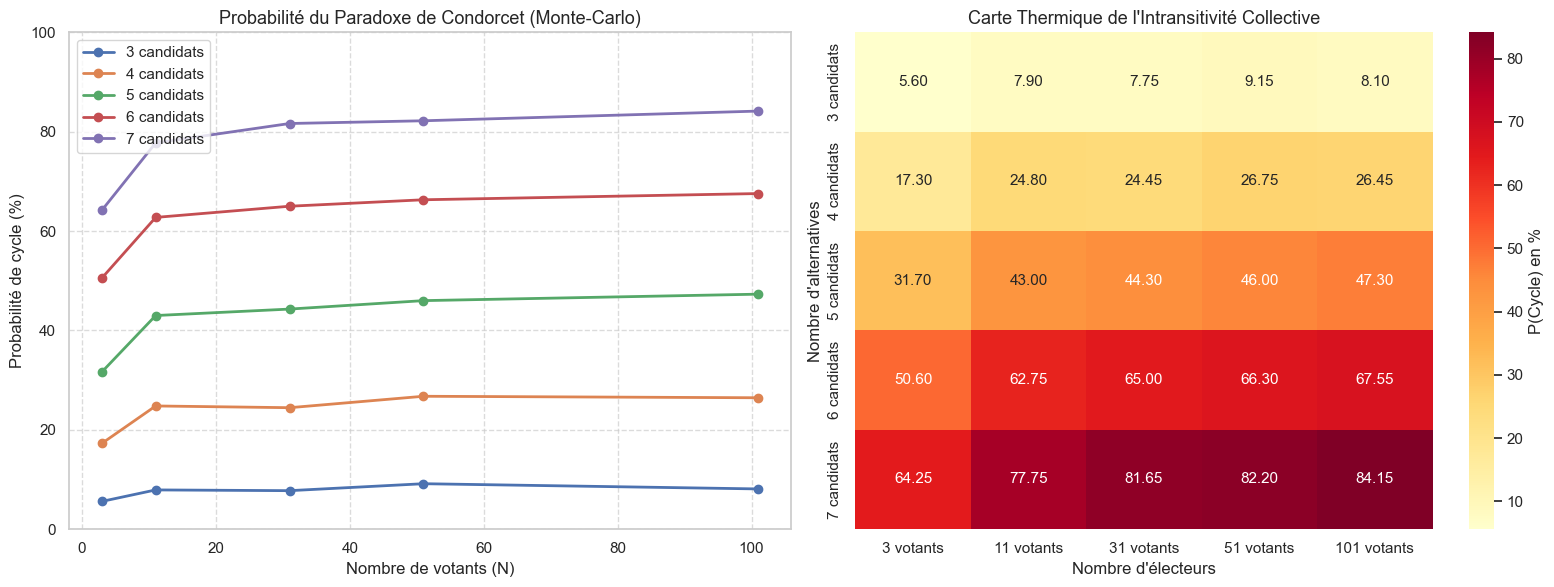

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Si vos données brutes dans resultats sont déjà entre 0 et 100, on ne multiplie plus par 100 :
donnees_pct = df_resultats if df_resultats.values.max() <= 100 else df_resultats / 100
matrice_pct = resultats if resultats.max() <= 100 else resultats / 100

# Graphique 1 : Courbes d'évolution
for i, m in enumerate(candidats_liste):
    axes[0].plot(votants_liste, matrice_pct[i, :], marker='o', label=f"{m} candidats", linewidth=2)

axes[0].set_title("Probabilité du Paradoxe de Condorcet (Monte-Carlo)")
axes[0].set_xlabel("Nombre de votants (N)")
axes[0].set_ylabel("Probabilité de cycle (%)")
axes[0].set_ylim(0, 100)
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle="--", alpha=0.7)

# Graphique 2 : Carte thermique (Heatmap)
sns.heatmap(donnees_pct, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'P(Cycle) en %'}, ax=axes[1])
axes[1].set_title("Carte Thermique de l'Intransitivité Collective")
axes[1].set_xlabel("Nombre d'électeurs")
axes[1].set_ylabel("Nombre d'alternatives")

plt.tight_layout()
plt.savefig("../assets/condorcet_simulation_results.png", dpi=300)
plt.show()

## 5. Interprétation des Résultats

L'analyse conjointe des courbes d'évolution et de la carte thermique met en évidence plusieurs propriétés structurelles fondamentales du paradoxe de Condorcet :

* **Sensibilité critique au nombre de candidats ($M$) :** Le nombre d'alternatives est le facteur déterminant de l'intransitivité collective. Pour 3 candidats, la probabilité d'un cycle reste inférieure à **9 %**. En revanche, dès que l'on atteint 7 candidats, le risque d'intransitivité dépasse les **80 %**, rendant l'existence d'un vainqueur majoritaire direct très improbable en univers non corrélé (*Impartial Culture*).
* **Convergence asymptotique rapide selon les votants ($N$) :** L'augmentation du nombre d'électeurs n'atténue pas le paradoxe. Dès $N \ge 31$, la probabilité se stabilise autour de sa limite théorique asymptotique ($N \to \infty$), confirmant que les grands corps électoraux sont structurellement tout aussi vulnérables aux cycles que les petits comités.
* **Risque de manipulation de l'ordre du jour (*Agenda Setting*) :** En présence d'un cycle ($A \succ B \succ C \succ A$), aucun choix ne possède de légitimité majoritaire absolue face à tous les autres. L'acteur qui contrôle l'ordre des votes par paires peut mathématiquement prédéterminer le gagnant final.

## 6. Conclusion de l'Exploration

Cette modélisation numérique démontre empiriquement les limites inhérentes au vote par duels majoritaires :

1. **La rationalité individuelle ne garantit pas la rationalité collective :** Même si chaque votant classe les options de manière parfaitement transitive et rationnelle, l'agrégation démocratique pairwise peut produire un ordre circulaire incohérent.
2. **Nécessité de systèmes de départage alternatifs :** Lorsque le paradoxe survient (absence de vainqueur de Condorcet), les organisations doivent recourir à des méthodes de résolution adaptées :
   * **Méthode de Borda :** Pondération par les rangs pour identifier le candidat de compromis moyen.
   * **Méthodes de Condorcet avec complétion (ex. Schulze, Ranked Pairs) :** Résolution algorithmique des cycles pour minimiser les incohérences majoritaires.
   * **Jugement Majoritaire :** Évaluation par mentions qualitatives indépendantes afin d'éliminer les biais d'ordonnancement pairwise.